In [5]:
!pip install pandas numpy matplotlib seaborn plotly scipy statsmodels scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, chi2_contingency, spearmanr
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

print("All imports successful ✅")

All imports successful ✅


In [7]:
fg = pd.read_csv('fear_greed_index - fear_greed_index.csv')
ht = pd.read_csv('historical_data.csv')

print("Fear Greed shape:", fg.shape)
print("Historical Data shape:", ht.shape)

Fear Greed shape: (2644, 4)
Historical Data shape: (211224, 16)


In [10]:
# Parse dates
ht['datetime'] = pd.to_datetime(ht['Timestamp IST'], format='%d-%m-%Y %H:%M')
ht['date'] = ht['datetime'].dt.date.astype(str)
ht['hour'] = ht['datetime'].dt.hour
ht['dayofweek'] = ht['datetime'].dt.dayofweek
ht['month'] = ht['datetime'].dt.month

fg['date'] = pd.to_datetime(fg['date']).dt.date.astype(str)

print("Date parsing done ✅")
print("Sample ht dates:", ht['date'].head(3).tolist())
print("Sample fg dates:", fg['date'].head(3).tolist())

Date parsing done ✅
Sample ht dates: ['2024-12-02', '2024-12-02', '2024-12-02']
Sample fg dates: ['2018-02-01', '2018-02-02', '2018-02-03']


In [11]:
merged = ht.merge(fg[['date', 'value', 'classification']], on='date', how='left')
merged.rename(columns={'value': 'fg_value', 'classification': 'sentiment'}, inplace=True)

print("Merged shape:", merged.shape)
print("Sentiment null count:", merged['sentiment'].isna().sum())
print("\nSentiment distribution:")
print(merged['sentiment'].value_counts())

Merged shape: (211224, 23)
Sentiment null count: 6

Sentiment distribution:
sentiment
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [12]:
merged['net_pnl'] = merged['Closed PnL'] - merged['Fee']
merged['is_win'] = merged['Closed PnL'] > 0
merged['is_loss'] = merged['Closed PnL'] < 0
merged['is_open'] = merged['Direction'].isin(['Open Long', 'Open Short'])
merged['is_close'] = merged['Direction'].isin(['Close Long', 'Close Short'])
merged['fee_pct'] = merged['Fee'] / (merged['Size USD'] + 1e-9) * 100

SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
SENTIMENT_COLORS = {
    'Extreme Fear': '#d73027',
    'Fear': '#f46d43',
    'Neutral': '#fee090',
    'Greed': '#74add1',
    'Extreme Greed': '#313695'
}

print("Derived columns created ✅")
print("Columns now:", merged.shape[1], "total")
print(merged[['net_pnl', 'is_win', 'is_loss', 'fee_pct']].head(3))

Derived columns created ✅
Columns now: 29 total
    net_pnl  is_win  is_loss   fee_pct
0 -0.345404   False    False  0.004388
1 -0.005600   False    False  0.004386
2 -0.050431   False    False  0.004383


=== Avg Closed PnL by Sentiment ===
                mean  median         sum  count
sentiment                                      
Extreme Fear   34.54     0.0   739110.25  21400
Fear           54.29     0.0  3357155.44  61837
Neutral        34.31     0.0  1292920.68  37686
Greed          42.74     0.0  2150129.27  50303
Extreme Greed  67.89     0.0  2715171.31  39992


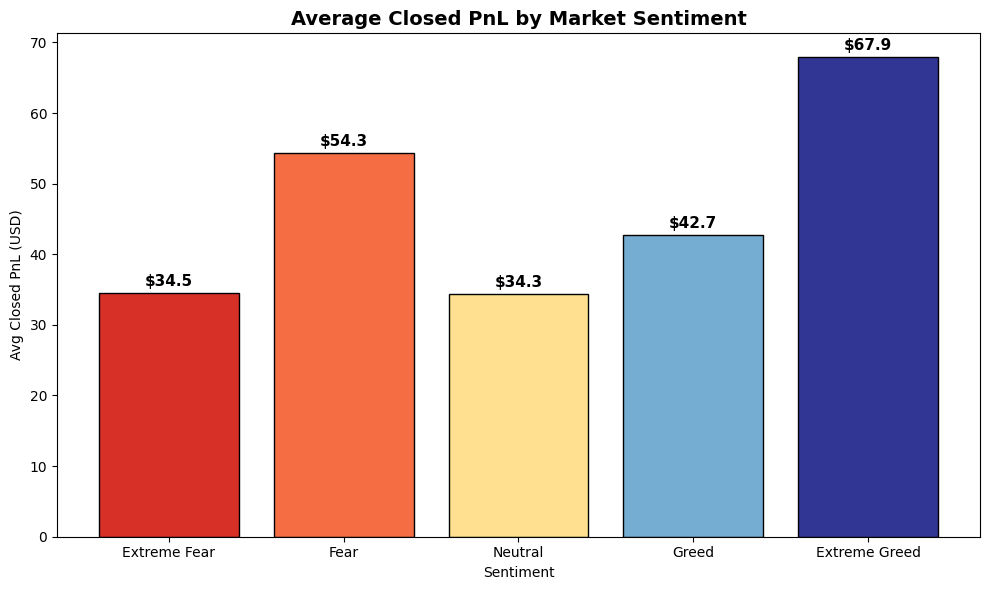

Chart saved ✅


In [13]:
pnl_by_sent = merged.groupby('sentiment')['Closed PnL'].agg(['mean', 'median', 'sum', 'count']).reindex(SENTIMENT_ORDER)

print("=== Avg Closed PnL by Sentiment ===")
print(pnl_by_sent.round(2))

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(SENTIMENT_ORDER, pnl_by_sent['mean'], 
               color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER], edgecolor='black')

for bar, val in zip(bars, pnl_by_sent['mean']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'${val:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.title('Average Closed PnL by Market Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Avg Closed PnL (USD)')
plt.tight_layout()
plt.savefig('pnl_by_sentiment.png', dpi=150)
plt.show()
print("Chart saved ✅")

=== Win Rate by Sentiment ===
sentiment
Extreme Fear     76.22
Fear             87.29
Neutral          82.39
Greed            76.89
Extreme Greed    89.17
Name: is_win, dtype: float64


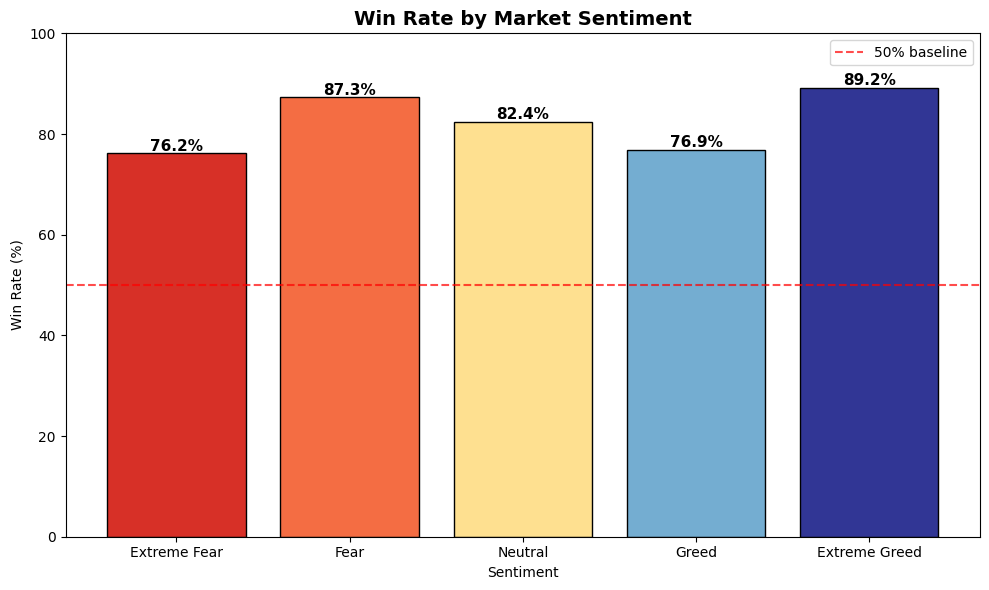

Chart saved ✅


In [14]:
closed_trades = merged[merged['Closed PnL'] != 0]
win_rate = closed_trades.groupby('sentiment')['is_win'].mean().reindex(SENTIMENT_ORDER) * 100

print("=== Win Rate by Sentiment ===")
print(win_rate.round(2))

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(SENTIMENT_ORDER, win_rate,
               color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER], edgecolor='black')

for bar, val in zip(bars, win_rate):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% baseline')
plt.title('Win Rate by Market Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.savefig('winrate_by_sentiment.png', dpi=150)
plt.show()
print("Chart saved ✅")

=== Close Long Avg PnL by Sentiment ===
sentiment
Extreme Fear     81.20
Fear             83.00
Neutral          52.82
Greed            88.96
Extreme Greed    61.83
Name: Closed PnL, dtype: float64

=== Close Short Avg PnL by Sentiment ===
sentiment
Extreme Fear     123.40
Fear             207.68
Neutral           94.80
Greed             55.20
Extreme Greed     28.97
Name: Closed PnL, dtype: float64


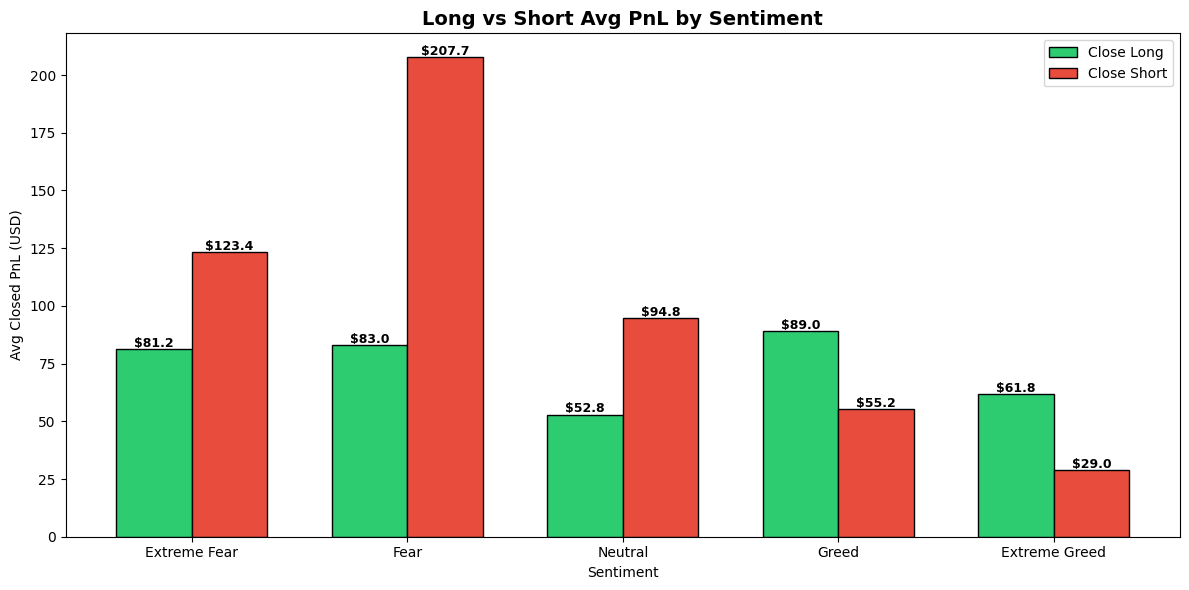

Chart saved ✅


In [15]:
long_pnl = merged[merged['Direction']=='Close Long'].groupby('sentiment')['Closed PnL'].mean().reindex(SENTIMENT_ORDER)
short_pnl = merged[merged['Direction']=='Close Short'].groupby('sentiment')['Closed PnL'].mean().reindex(SENTIMENT_ORDER)

print("=== Close Long Avg PnL by Sentiment ===")
print(long_pnl.round(2))
print("\n=== Close Short Avg PnL by Sentiment ===")
print(short_pnl.round(2))

# Plot
x = np.arange(len(SENTIMENT_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, long_pnl, width, label='Close Long', color='#2ecc71', edgecolor='black')
bars2 = ax.bar(x + width/2, short_pnl, width, label='Close Short', color='#e74c3c', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'${bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'${bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Long vs Short Avg PnL by Sentiment', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Avg Closed PnL (USD)')
ax.set_xticks(x)
ax.set_xticklabels(SENTIMENT_ORDER)
ax.legend()
plt.tight_layout()
plt.savefig('long_short_pnl.png', dpi=150)
plt.show()
print("Chart saved ✅")

=== Maker vs Taker Avg PnL by Sentiment ===
               Maker (Limit)  Taker (Market)
sentiment                                   
Extreme Fear           37.45           32.31
Fear                   80.84           36.66
Neutral                25.55           39.70
Greed                  84.98           16.24
Extreme Greed          87.52           55.98


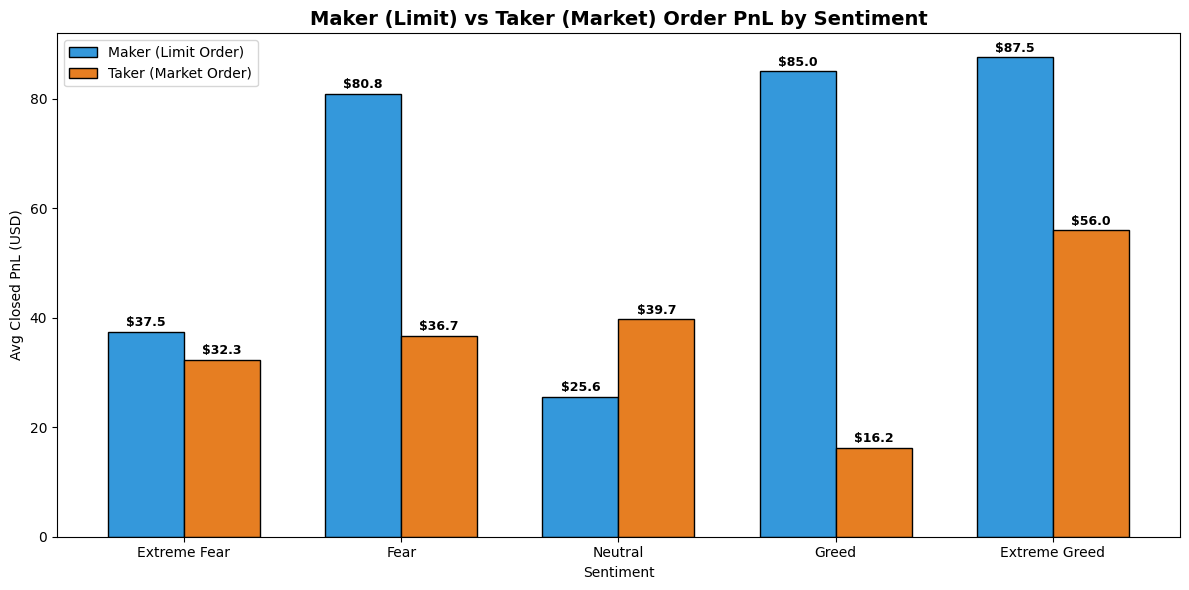

Chart saved ✅


In [16]:
maker_taker = merged.groupby(['sentiment', 'Crossed'])['Closed PnL'].mean().unstack()
maker_taker.columns = ['Maker (Limit)', 'Taker (Market)']
maker_taker = maker_taker.reindex(SENTIMENT_ORDER)

print("=== Maker vs Taker Avg PnL by Sentiment ===")
print(maker_taker.round(2))

# Plot
x = np.arange(len(SENTIMENT_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, maker_taker['Maker (Limit)'], width, label='Maker (Limit Order)', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, maker_taker['Taker (Market)'], width, label='Taker (Market Order)', color='#e67e22', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'${bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'${bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Maker (Limit) vs Taker (Market) Order PnL by Sentiment', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Avg Closed PnL (USD)')
ax.set_xticks(x)
ax.set_xticklabels(SENTIMENT_ORDER)
ax.legend()
plt.tight_layout()
plt.savefig('maker_taker_pnl.png', dpi=150)
plt.show()
print("Chart saved ✅")

In [17]:
whales = merged[merged['Size USD'] > 100000]

whale_by_sent = whales.groupby('sentiment').agg(
    count=('Closed PnL', 'count'),
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum')
).reindex(SENTIMENT_ORDER)

print("=== Whale Trades (>$100k) by Sentiment ===")
print(whale_by_sent.round(2))

# Plot dual axis
fig, ax1 = plt.subplots(figsize=(12, 6))

ax2 = ax1.twinx()
bars = ax1.bar(SENTIMENT_ORDER, whale_by_sent['count'],
               color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER],
               edgecolor='black', alpha=0.8, label='Trade Count')
line = ax2.plot(SENTIMENT_ORDER, whale_by_sent['avg_pnl'],
                color='black', marker='o', linewidth=2.5,
                markersize=8, label='Avg PnL')

for bar, val in zip(bars, whale_by_sent['count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(int(val)), ha='center', fontsize=11, fontweight='bold')

ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Number of Whale Trades', color='black')
ax2.set_ylabel('Avg PnL (USD)', color='black

SyntaxError: unterminated string literal (detected at line 29) (1058678251.py, line 29)

=== Whale Trades (>$100k) by Sentiment ===
               count  avg_pnl  total_pnl
sentiment                               
Extreme Fear     170  1629.09  276944.94
Fear             830   976.61  810585.37
Neutral          225   882.70  198607.89
Greed            420   343.10  144103.49
Extreme Greed     61  1134.95   69232.19


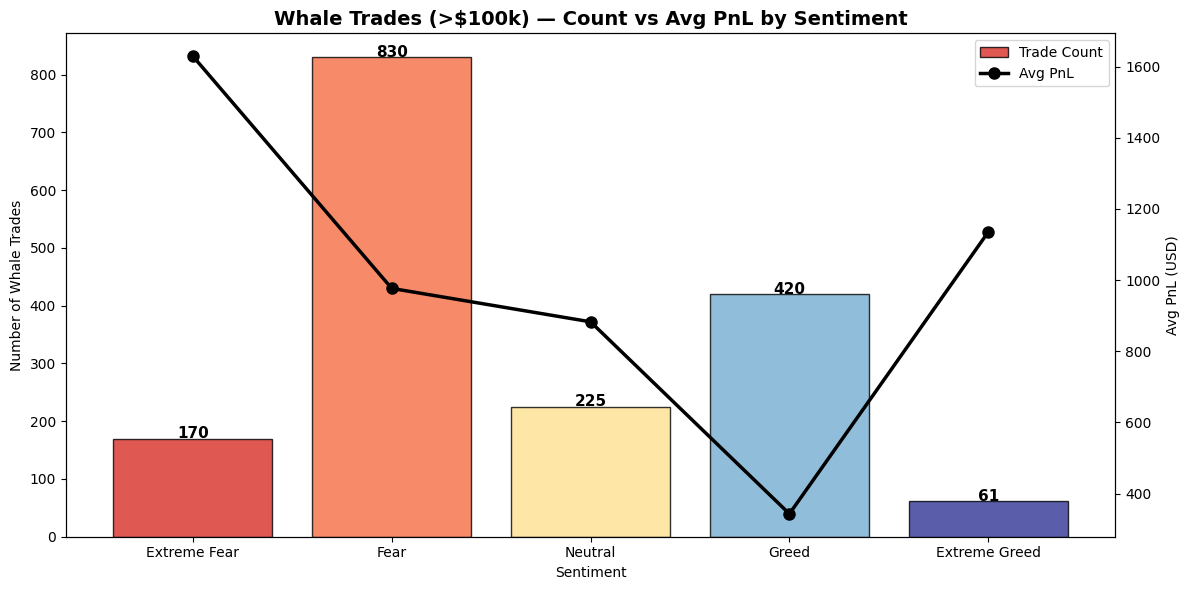

Chart saved ✅


In [18]:
whales = merged[merged['Size USD'] > 100000]

whale_by_sent = whales.groupby('sentiment').agg(
    count=('Closed PnL', 'count'),
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum')
).reindex(SENTIMENT_ORDER)

print("=== Whale Trades (>$100k) by Sentiment ===")
print(whale_by_sent.round(2))

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

bars = ax1.bar(SENTIMENT_ORDER, whale_by_sent['count'],
               color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER],
               edgecolor='black', alpha=0.8, label='Trade Count')
line = ax2.plot(SENTIMENT_ORDER, whale_by_sent['avg_pnl'],
                color='black', marker='o', linewidth=2.5,
                markersize=8, label='Avg PnL')

for bar, val in zip(bars, whale_by_sent['count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(int(val)), ha='center', fontsize=11, fontweight='bold')

ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Number of Whale Trades')
ax2.set_ylabel('Avg PnL (USD)')
ax1.set_title('Whale Trades (>$100k) — Count vs Avg PnL by Sentiment', fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('whale_trades.png', dpi=150)
plt.show()
print("Chart saved ✅")


=== Avg PnL by Sentiment Streak Length ===
streak_bin      1-3d    4-7d  8-14d  15-30d  30d+
sentiment                                        
Extreme Fear   26.25   80.68    NaN     NaN   NaN
Fear           80.56   36.06  29.89     NaN   NaN
Neutral        29.95  101.23  43.34     NaN   NaN
Greed          92.20   23.91  27.86   19.42  3.54
Extreme Greed  31.49   51.59  76.19   71.16   NaN


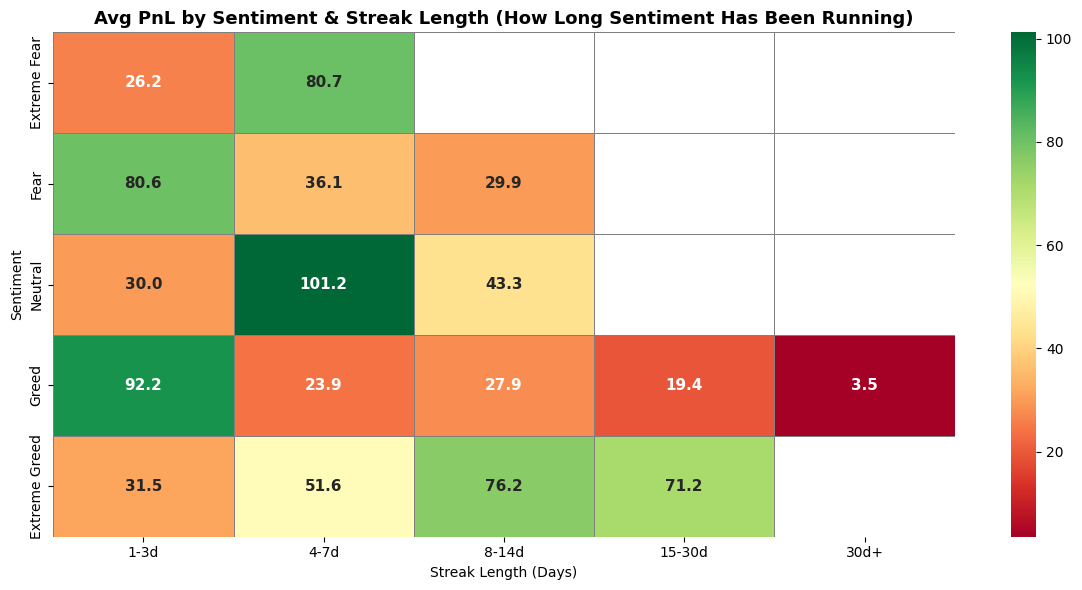

Chart saved ✅


In [19]:
fg_sorted = fg.sort_values('date').copy()
fg_sorted['streak_id'] = (fg_sorted['classification'] != fg_sorted['classification'].shift()).cumsum()

streak_info = fg_sorted.groupby('streak_id').agg(
    sentiment=('classification', 'first'),
    streak_len=('classification', 'count')
).reset_index()

fg_sorted = fg_sorted.merge(streak_info[['streak_id', 'streak_len']], on='streak_id')
merged_streak = merged.merge(fg_sorted[['date', 'streak_len', 'streak_id']], on='date', how='left')

merged_streak['streak_bin'] = pd.cut(merged_streak['streak_len'],
    bins=[0, 3, 7, 14, 30, 200],
    labels=['1-3d', '4-7d', '8-14d', '15-30d', '30d+'])

streak_pnl = merged_streak.groupby(['sentiment', 'streak_bin'])['Closed PnL'].mean().unstack()
streak_pnl = streak_pnl.reindex(SENTIMENT_ORDER)

print("=== Avg PnL by Sentiment Streak Length ===")
print(streak_pnl.round(2))

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(streak_pnl, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Avg PnL by Sentiment & Streak Length (How Long Sentiment Has Been Running)',
          fontsize=13, fontweight='bold')
plt.xlabel('Streak Length (Days)')
plt.ylabel('Sentiment')
plt.tight_layout()
plt.savefig('streak_effect.png', dpi=150)
plt.show()
print("Chart saved ✅")

=== Top 5 Coins by Total PnL per Sentiment ===

Extreme Fear:
   Coin   mean       sum  count
   HYPE  46.90 482083.81  10278
    ETH 196.93 274320.23   1393
    SOL  56.01 105179.50   1878
MELANIA 218.34  97379.17    446
    SUI 179.88  44788.99    249

Fear:
   Coin   mean       sum  count
   HYPE  30.06 840306.35  27951
    SOL 189.47 741594.29   3914
    ETH 236.86 675064.58   2850
    BTC  48.90 482649.64   9870
MELANIA  99.17 196849.12   1985

Neutral:
Coin    mean       sum  count
 SOL  216.70 303376.19   1400
HYPE   17.32 300100.24  17324
@107   52.15 219551.95   4210
 BTC   34.92 165980.35   4753
DOGE 2969.47 115809.47     39

Greed:
Coin   mean       sum  count
@107  86.25 724342.31   8398
 SOL 284.80 451690.01   1586
 ETH  98.22 351036.01   3574
HYPE  24.57 166307.64   6769
 ZRO 124.84 143815.51   1152

Extreme Greed:
     Coin   mean        sum  count
     @107 191.16 1988618.87  10403
     HYPE  28.10  159686.56   5683
      BTC  41.41  100882.71   2436
PURR/USDC  52.37   

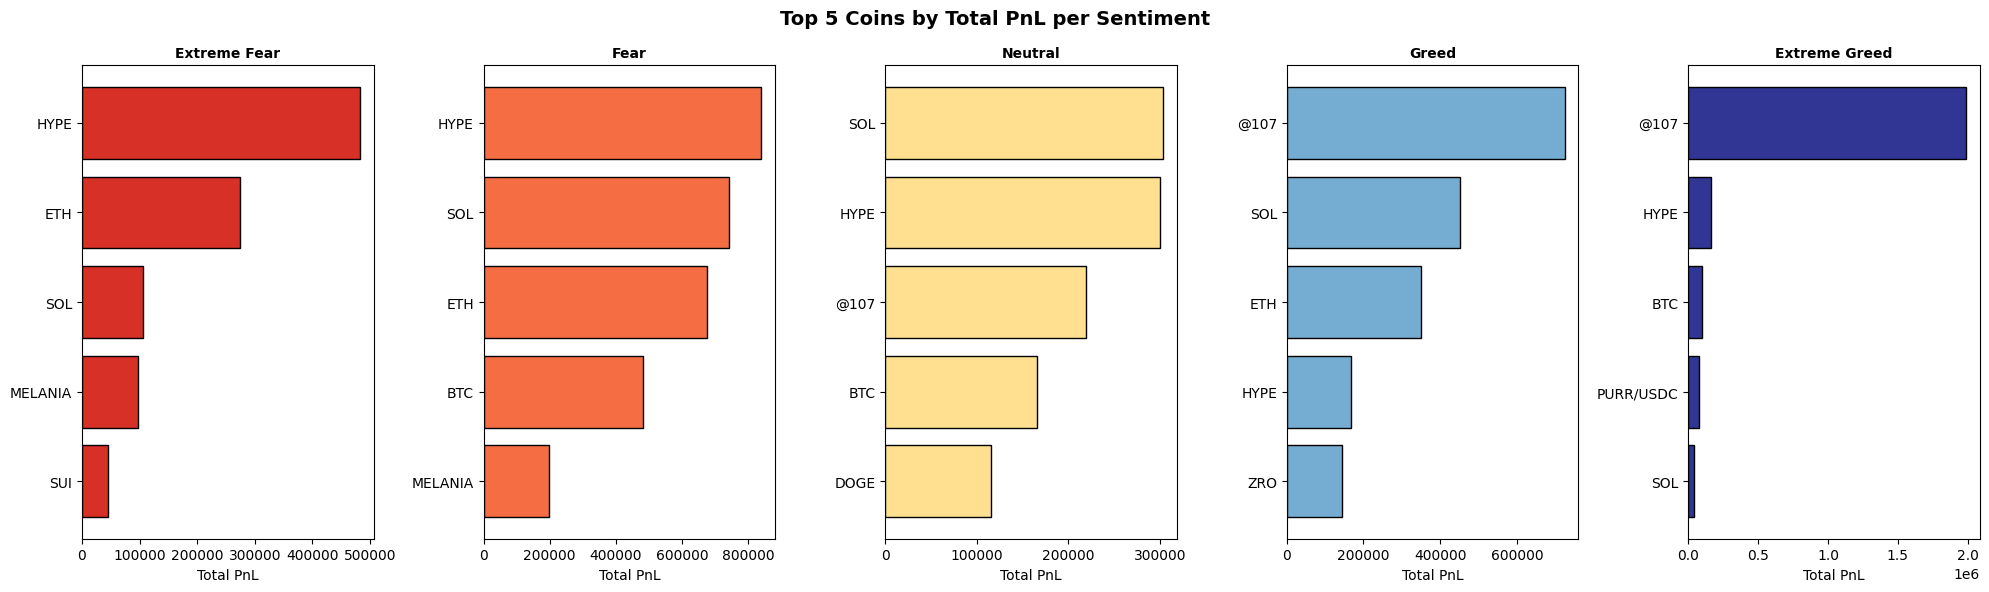

Chart saved ✅


In [20]:
coin_sent = merged.groupby(['sentiment', 'Coin'])['Closed PnL'].agg(['mean', 'sum', 'count']).reset_index()

# Top 5 coins per sentiment by total PnL
top_coins_per_sent = []
for sent in SENTIMENT_ORDER:
    top = coin_sent[coin_sent['sentiment'] == sent].nlargest(5, 'sum')
    top_coins_per_sent.append(top)

top_coins_df = pd.concat(top_coins_per_sent)

print("=== Top 5 Coins by Total PnL per Sentiment ===")
for sent in SENTIMENT_ORDER:
    print(f"\n{sent}:")
    df = top_coins_df[top_coins_df['sentiment'] == sent][['Coin', 'mean', 'sum', 'count']]
    print(df.round(2).to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
for i, sent in enumerate(SENTIMENT_ORDER):
    data = top_coins_df[top_coins_df['sentiment'] == sent]
    axes[i].barh(data['Coin'], data['sum'],
                 color=SENTIMENT_COLORS[sent], edgecolor='black')
    axes[i].set_title(sent, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Total PnL')
    axes[i].invert_yaxis()

plt.suptitle('Top 5 Coins by Total PnL per Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('coin_rotation.png', dpi=150)
plt.show()
print("Chart saved ✅")

=== Trader Consistency (Sharpe-like Score) ===
  Account_short       mean        std  count  sharpe
0   0x7f4f29...    573.094    873.411     26   0.656
1   0xa0feb3...   1660.982   2678.373     64   0.620
2   0x75f7ee...   2596.544   4762.374    146   0.545
3   0xaf40fd...   1087.942   2029.270     20   0.536
4   0xae5eac...   4523.041   8542.121     15   0.529
5   0x513b86...  21549.296  42171.745     39   0.511
6   0x2c229d...   2444.319   4867.743     69   0.502
7   0x420ab4...   9975.280  20797.396     20   0.480
8   0x4acb90...  11685.294  25344.268     58   0.461
9   0x430f09...  14876.495  32725.083     28   0.455


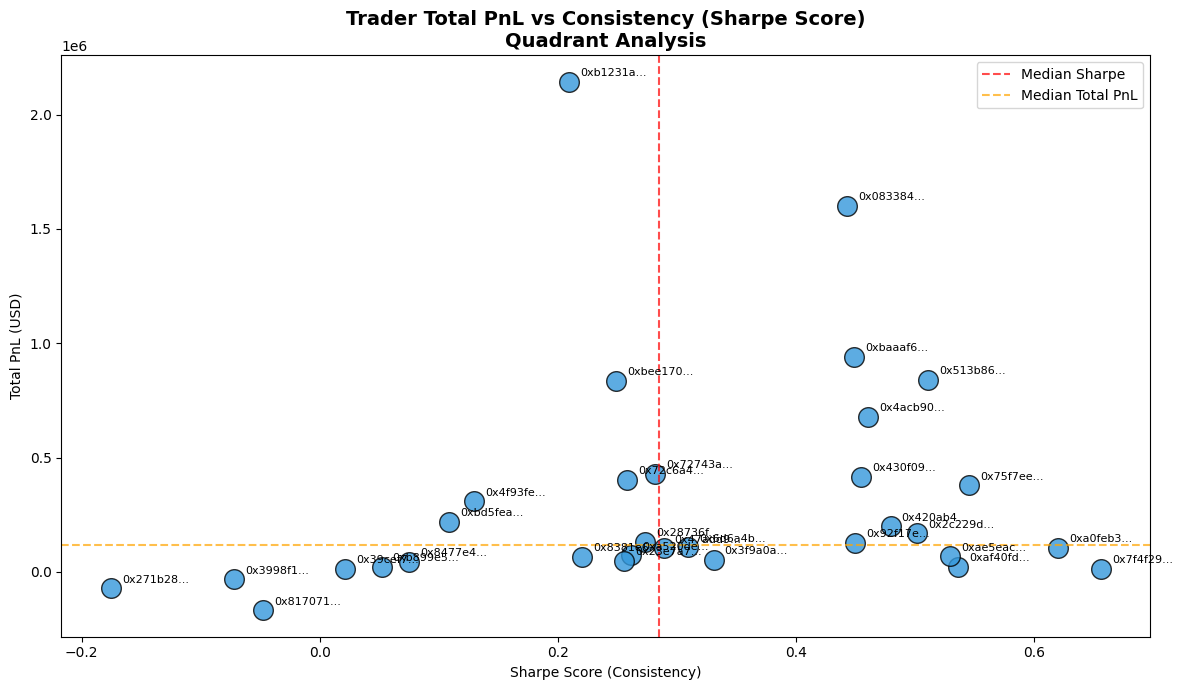

Chart saved ✅


In [21]:
daily_pnl = merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
sharpe_df = daily_pnl.groupby('Account')['Closed PnL'].agg(['mean', 'std', 'count'])
sharpe_df['sharpe'] = sharpe_df['mean'] / (sharpe_df['std'] + 1e-9)
sharpe_df = sharpe_df.sort_values('sharpe', ascending=False).reset_index()
sharpe_df['Account_short'] = sharpe_df['Account'].str[:8] + '...'

print("=== Trader Consistency (Sharpe-like Score) ===")
print(sharpe_df[['Account_short', 'mean', 'std', 'count', 'sharpe']].round(3).head(10))

# Total PnL per account
total_pnl = merged.groupby('Account')['Closed PnL'].sum().reset_index()
total_pnl.columns = ['Account', 'total_pnl']
sharpe_df = sharpe_df.merge(total_pnl, on='Account')

# Plot scatter: total PnL vs Sharpe
plt.figure(figsize=(12, 7))
plt.scatter(sharpe_df['sharpe'], sharpe_df['total_pnl'],
            s=200, color='#3498db', edgecolor='black', alpha=0.8)

for _, row in sharpe_df.iterrows():
    plt.annotate(row['Account_short'],
                (row['sharpe'], row['total_pnl']),
                textcoords='offset points', xytext=(8, 4), fontsize=8)

plt.axvline(x=sharpe_df['sharpe'].median(), color='red',
            linestyle='--', alpha=0.7, label='Median Sharpe')
plt.axhline(y=sharpe_df['total_pnl'].median(), color='orange',
            linestyle='--', alpha=0.7, label='Median Total PnL')

plt.title('Trader Total PnL vs Consistency (Sharpe Score)\nQuadrant Analysis',
          fontsize=14, fontweight='bold')
plt.xlabel('Sharpe Score (Consistency)')
plt.ylabel('Total PnL (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('sharpe_scatter.png', dpi=150)
plt.show()
print("Chart saved ✅")

In [22]:
from scipy.stats import kruskal, mannwhitneyu, spearmanr

# Test 1: Is PnL significantly different across sentiments?
groups = [merged[merged['sentiment']==s]['Closed PnL'].dropna() for s in SENTIMENT_ORDER]
stat, p = kruskal(*groups)
print("=== Kruskal-Wallis Test: PnL across all sentiments ===")
print(f"H-statistic: {stat:.2f}")
print(f"P-value: {p:.6f}")
print(f"Result: {'SIGNIFICANT ✅' if p < 0.05 else 'NOT significant ❌'}")

# Test 2: Extreme Fear vs Extreme Greed
ef = merged[merged['sentiment']=='Extreme Fear']['Closed PnL'].dropna()
eg = merged[merged['sentiment']=='Extreme Greed']['Closed PnL'].dropna()
stat2, p2 = mannwhitneyu(ef, eg, alternative='two-sided')
print("\n=== Mann-Whitney U: Extreme Fear vs Extreme Greed ===")
print(f"U-statistic: {stat2:.2f}")
print(f"P-value: {p2:.6f}")
print(f"Result: {'SIGNIFICANT ✅' if p2 < 0.05 else 'NOT significant ❌'}")

# Test 3: Spearman correlation FG value vs PnL
corr, p3 = spearmanr(merged['fg_value'].dropna(),
                      merged.loc[merged['fg_value'].notna(), 'Closed PnL'])
print("\n=== Spearman Correlation: FG Value vs Closed PnL ===")
print(f"Correlation: {corr:.4f}")
print(f"P-value: {p3:.6f}")
print(f"Result: {'SIGNIFICANT ✅' if p3 < 0.05 else 'NOT significant ❌'}")

=== Kruskal-Wallis Test: PnL across all sentiments ===
H-statistic: 1227.00
P-value: 0.000000
Result: SIGNIFICANT ✅

=== Mann-Whitney U: Extreme Fear vs Extreme Greed ===
U-statistic: 379741541.00
P-value: 0.000000
Result: SIGNIFICANT ✅

=== Spearman Correlation: FG Value vs Closed PnL ===
Correlation: 0.0381
P-value: 0.000000
Result: SIGNIFICANT ✅


=== Smart Money vs Dumb Money by Sentiment ===
sentiment    Extreme Fear   Fear  Neutral   Greed  Extreme Greed
trader_tier                                                     
Q1 Loser           -22.58  29.29    11.05  -50.84          19.53
Q2                 -18.43   2.95     2.87   24.39          39.18
Q3                 158.90  81.21    13.48   34.04          35.17
Q4 Winner           45.18  65.57    58.35  102.43         172.06


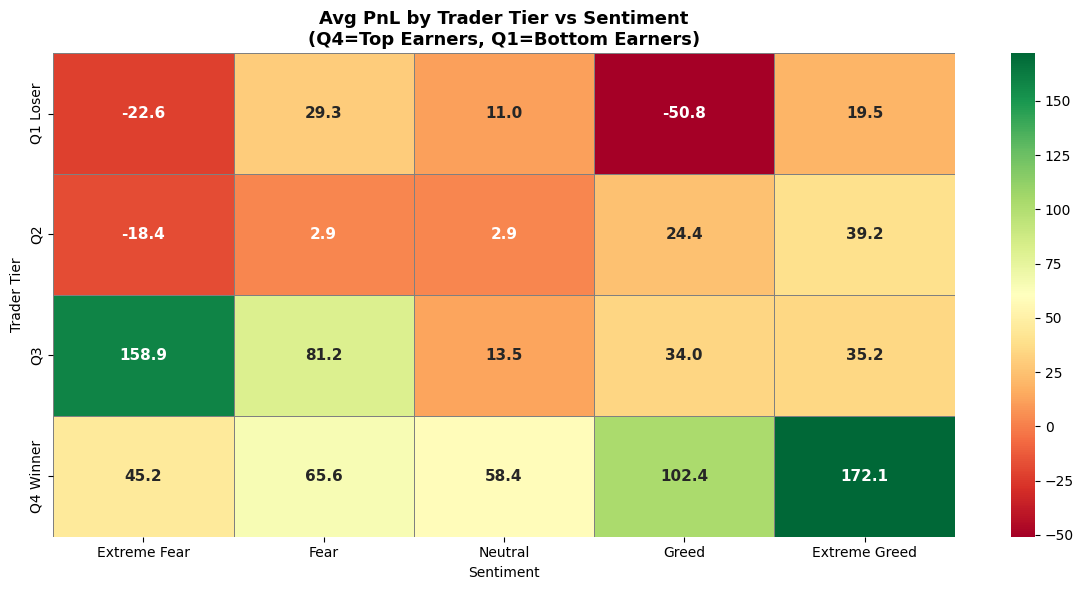

Chart saved ✅


In [23]:
total_pnl = merged.groupby('Account')['Closed PnL'].sum()
quartiles = pd.qcut(total_pnl, q=4, labels=['Q1 Loser', 'Q2', 'Q3', 'Q4 Winner'])
tier_map = quartiles.to_dict()
merged['trader_tier'] = merged['Account'].map(tier_map)

tier_sent = merged.groupby(['trader_tier', 'sentiment'])['Closed PnL'].mean().unstack()
tier_sent = tier_sent.reindex(SENTIMENT_ORDER, axis=1)

print("=== Smart Money vs Dumb Money by Sentiment ===")
print(tier_sent.round(2))

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(tier_sent, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Avg PnL by Trader Tier vs Sentiment\n(Q4=Top Earners, Q1=Bottom Earners)',
          fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Trader Tier')
plt.tight_layout()
plt.savefig('smart_money.png', dpi=150)
plt.show()
print("Chart saved ✅")